In [1]:
import glob

# import seaborn as sns
# import warnings
import itertools
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from matplotlib.ticker import FuncFormatter

# warnings.simplefilter(action='ignore', category=FutureWarning)
from tqdm.auto import tqdm

import pathlib

In [2]:
plt.rcParams["figure.dpi"] = 150
# plt.rcParams["font.sans-serif"] = "Arial"

In [3]:
nicename = {
    'NaturalgasCCGTwithCCSnewOT' : 'GasCCS', 
    'NaturalgasOCGTnew' : 'Gas', 
    'Windoffshore' : 'OffWind', 
    'Windonshore' : 'OnWind',
}
    

In [4]:
colordict = {
    "GasCCS": "#b20101",
    "Gas": "#d35050",
    "HydroRes": "#08ad97",
    "HydroRoR": "#4adbc8",
    "OnWind": "#235ebc",
    "Solar": "#f9d002",
    #"Import": "#8a1caf",
    "OffWind": "#6895dd",
    #"Lion": "#baf238",
    #"PumpedHydro": "#51dbcc",
}

In [5]:
resultspath = pathlib.Path("/home/oskar/Desktop/uio/research_projects/phd-thesis/thesis_git/scripts/data")

In [6]:
desired_regions = [
    "AT", "BE", "BG", "CH", "CZ", "DE",
    "DK", "EE", "ES", "FI", "FR", "UK",
    "GR", "HR", "HU", "IE", "IT", "LT",
    "LU", "LV", "NL", "NO", "PL", "PT",
    "RO", "SE", "SI", "SK",
  ]
    

In [7]:
europe = (
    gpd.read_file('/home/oskar/shared_input/geodata/onshore/shapes/NUTS_RG_10M_2021_4326.geojson')
    .replace({'EL' : 'GR'})
    .query("NUTS_ID == @desired_regions")
    .loc[:,['NUTS_ID','geometry']]
    .set_index('NUTS_ID')
)

rectx1 = -12
rectx2 = 44
recty1 = 33
recty2 = 72


polygon = Polygon(
    [
        (rectx1, recty1),
        (rectx1, recty2),
        (rectx2, recty2),
        (rectx2, recty1),
        (rectx1, recty1),
    ]
)

europe=gpd.clip(europe,polygon)

In [10]:
gpd.read_file('/home/oskar/shared_input/geodata/onshore/shapes/NUTS_RG_10M_2021_4326.geojson').query("CNTR_CODE == 'NO' & LEVL_CODE == 2")

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
1937,NO09,2,NO,Agder og Sør-Østlandet,Agder og Sør-Østlandet,0.0,0,0,"MULTIPOLYGON (((10.57569 59.18298, 10.53617 59..."
1942,NO0A,2,NO,Vestlandet,Vestlandet,0.0,0,0,"MULTIPOLYGON (((8.76459 63.18458, 8.88642 63.1..."
1947,NO0B,2,NO,Jan Mayen and Svalbard,Jan Mayen and Svalbard,NaN,0,0,"MULTIPOLYGON (((32.34947 80.08196, 31.90668 80..."
1990,NO02,2,NO,Innlandet,Innlandet,0.0,0,0,"POLYGON ((10.90848 62.6949, 11.14154 62.65254,..."
1998,NO06,2,NO,Trøndelag,Trøndelag,0.0,0,0,"MULTIPOLYGON (((11.93334 65.11909, 11.92404 65..."
1999,NO07,2,NO,Nord-Norge,Nord-Norge,0.0,0,0,"MULTIPOLYGON (((25.58418 70.92051, 25.73814 70..."
2000,NO08,2,NO,Oslo og Viken,Oslo og Viken,0.0,0,0,"POLYGON ((8.65747 60.93672, 8.87938 60.89459, ..."


In [9]:
con = sqlite3.connect(resultspath / 'results.db')
pcap_base = pd.read_sql_query("SELECT z, g, level FROM var_tot_pcap_z", con).rename(columns={'z' : 'NUTS_ID', 'g' : 'technology'}).groupby(['NUTS_ID','technology']).sum().loc[:,['level']].rename(nicename)
#area_base = pd.read_sql_query("SELECT vre, z, r, value FROM area", con).rename(columns={'r' : 'NUTS_ID','value' : 'level'}).query("vre == 'Windonshore'").set_index('NUTS_ID').loc[:,['level']]

<Axes: xlabel='NUTS_ID'>

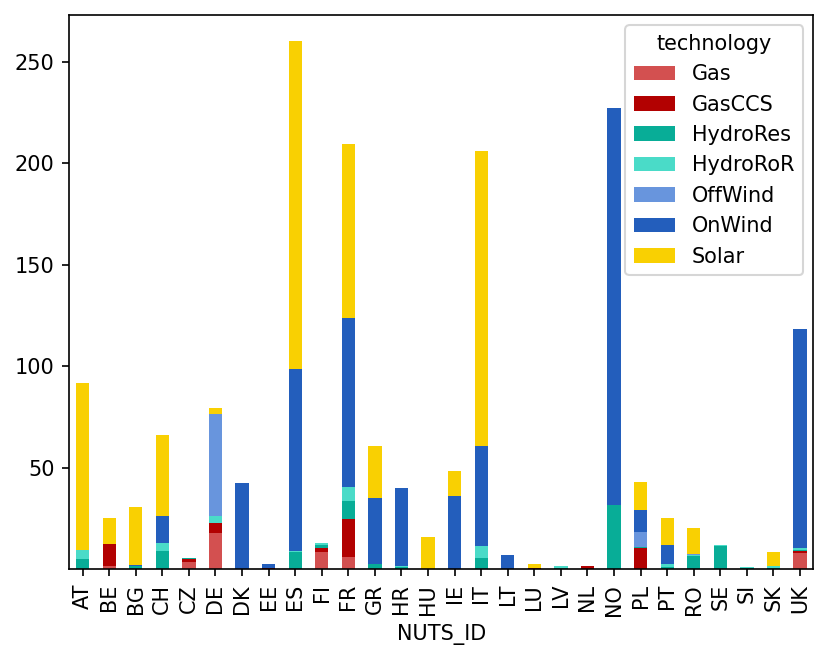

In [10]:
fig, ax = plt.subplots() 
pcap_base.unstack().droplevel(axis=1,level=0).plot.bar(ax=ax,stacked=True,color=colordict)

In [11]:
df = pcap_base.unstack().droplevel(axis=1,level=0).assign(geometry = europe.geometry)
gdf = gpd.GeoDataFrame(df, geometry = df.geometry)
gdf['x'] = gdf.geometry.representative_point().x
gdf['y'] = gdf.geometry.representative_point().y

In [12]:
# Function to format latitude labels
def format_latitude(y, pos):
    if y > 0:
        return f"{int(y):d}°N"
    elif y < 0:
        return f"{int(abs(y)):d}°S"
    else:
        return f"{int(y):d}°"

# Function to format longitude labels
def format_longitude(x, pos):
    if x > 0:
        return f"{int(x):d}°E"
    elif x < 0:
        return f"{int(abs(x)):d}°W"
    else:
        return f"{int(x):d}°"

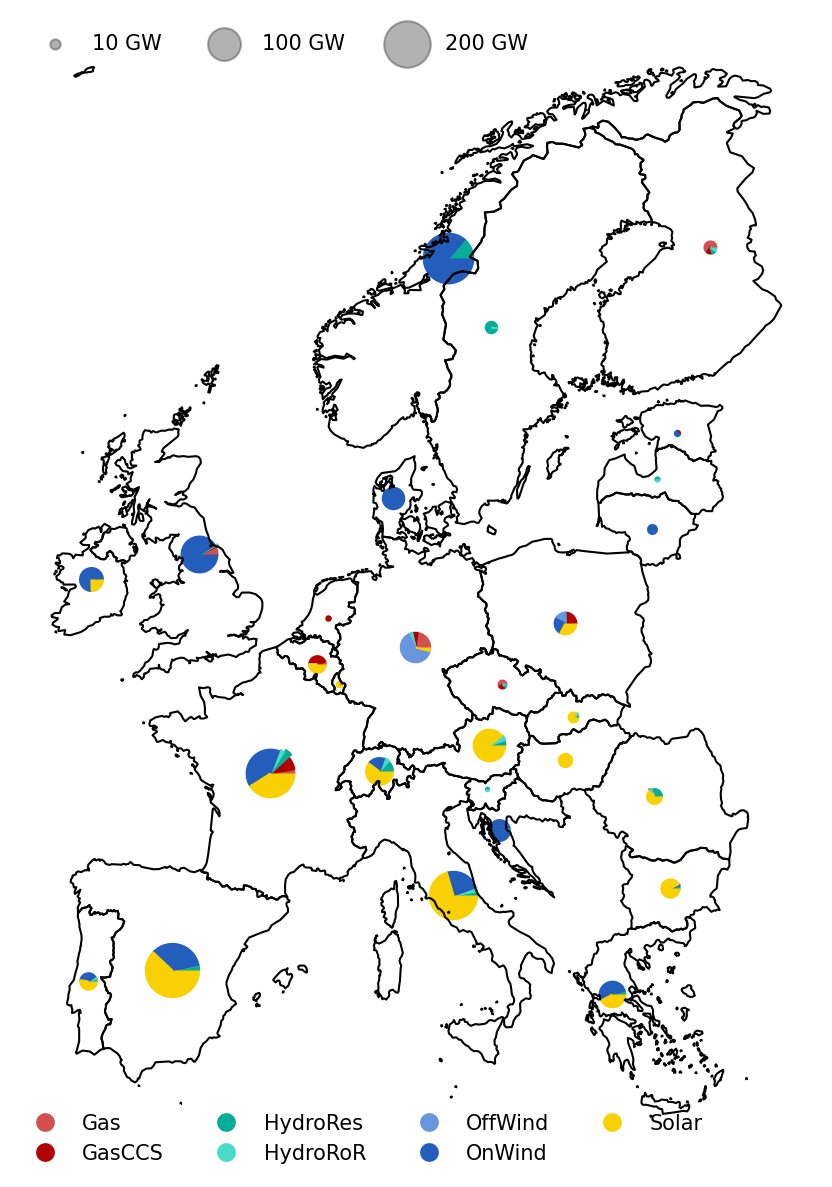

In [13]:
def draw_pie(dist, xpos, ypos, size, color_map, ax=None):
    """A function to plot pie charts"""
    """https://stackoverflow.com/questions/56337732/how-to-plot-scatter-pie-chart-using-matplotlib"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,8))

    # for incremental pie slices
    cumsum = np.cumsum(dist)
    cumsum = cumsum/ cumsum[-1]
    pie = [0] + cumsum.tolist()

    for r1, r2 in zip(pie[:-1], pie[1:]):
        angles = np.linspace(2 * np.pi * r1, 2 * np.pi * r2)
        x = [0] + np.cos(angles).tolist()
        y = [0] + np.sin(angles).tolist()

        xy = np.column_stack([x, y])

        ax.scatter([xpos], [ypos], marker=xy, s=size, color=color_map.pop(0))

    return ax

ax = gdf.boundary.plot(figsize=(16,10),color="black", linewidth=1) #Plot the polygon boundaries
# Define installed capacity legend elements before drawing pies
legend_elements_capacity = [plt.scatter([], [], c='k', alpha=0.3, s=area*2.5, label=f'{area} GW') for area in [10, 100, 200]]

for i, subframe in gdf.groupby("NUTS_ID"): #For each id
    values = subframe.iloc[0] #Extract its values as a series
    relevant_tech = []
    for tech in values.drop(['geometry','x','y']).index:    
        if values[tech] < 0.01:
            values = values.drop(tech)
        else:
            relevant_tech.append(tech)
    new_colordict = dict((k, colordict[k]) for k in relevant_tech if k in colordict)
    slice_sizes = values[list(new_colordict.keys())].to_list() #Extract the values from the values column as a list, like [1, 3]
    x = values.x #The x coord for the pie
    y = values.y #y
    pie_size = math.fsum(slice_sizes)*2.5
    color_map = list(new_colordict.values())
    draw_pie(dist=slice_sizes, xpos=x, ypos=y, size=pie_size, color_map=color_map, ax=ax)


#ax.xaxis.set_major_formatter(FuncFormatter(format_longitude))
#ax.yaxis.set_major_formatter(FuncFormatter(format_latitude))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(left=False, bottom=False)

# Add legends
capacity_legend = ax.legend(handles=legend_elements_capacity, scatterpoints=1, frameon=False, labelspacing=0.5, loc='upper left', ncols=3)
ax.add_artist(capacity_legend)

# Legend for pie chart colors
legend_elements_pie = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colordict[tech], markersize=10, label=tech) for tech in df.columns.drop('geometry')]

ax.legend(handles=legend_elements_pie, frameon=False, ncols=4, bbox_to_anchor = [0.88, 0.065])

plt.savefig('figures/baseline_map.pdf',bbox_inches='tight')

## Generation

In [14]:
gen_base = pd.read_sql_query("SELECT h, z, g, level FROM var_gen", con).rename(columns={'z' : 'NUTS_ID', 'g' : 'technology', 'h' : 'hour'})

In [97]:
countries = ['FI','CZ','PL','SI','SK']

In [98]:
gen_base.loc[:,['technology','NUTS_ID','level']].groupby(['technology','NUTS_ID']).sum().query("NUTS_ID == @countries & level > 0.01").head(60)

level
technology                 NUTS_ID              
HydroRes                   CZ        2613.311690
                           FI        6530.981635
                           PL        2793.576529
                           SI        2556.616639
                           SK        2884.090764
HydroRoR                   CZ         146.391533
                           FI        6158.703762
                           PL          81.987724
                           SI        1619.247039
                           SK        2130.938440
NaturalgasCCGTwithCCSnewOT CZ        1376.010721
                           FI        1720.430302
                           PL        9744.182640
NaturalgasOCGTnew          CZ         628.586173
                           FI        1634.391443
                           PL          50.504667
Solar                      PL       14401.290649
                           SK        8037.731407
Windoffshore               PL       37100.688979
Windonshore                PL       24226.195620

In [113]:
(
    gen_base.query("NUTS_ID == 'NO'")
    .level.sum()
)

641397.2144153437

In [102]:
# Define the start of the year
start_of_year = pd.Timestamp('2010-01-01 00:00:00')

gen_base['hour'] = gen_base['hour'].astype(float)
gen_base['datetime'] = gen_base['hour'].apply(lambda h: start_of_year + pd.Timedelta(hours=h))

gen_GR = (
    gen_base.query("NUTS_ID == 'GR'")
)

gen_PL = (
    gen_base.query("NUTS_ID == 'PL'")
)

In [110]:
gen_PL.loc[:,['technology','level']].groupby('technology').sum()

,level
technology,
HydroRes,2793.576529
HydroRoR,81.987724
NaturalgasCCGTwithCCSnewOT,9744.182640
NaturalgasOCGTnew,50.504667
Solar,14401.290649
Windoffshore,37100.688979
Windonshore,24226.195620


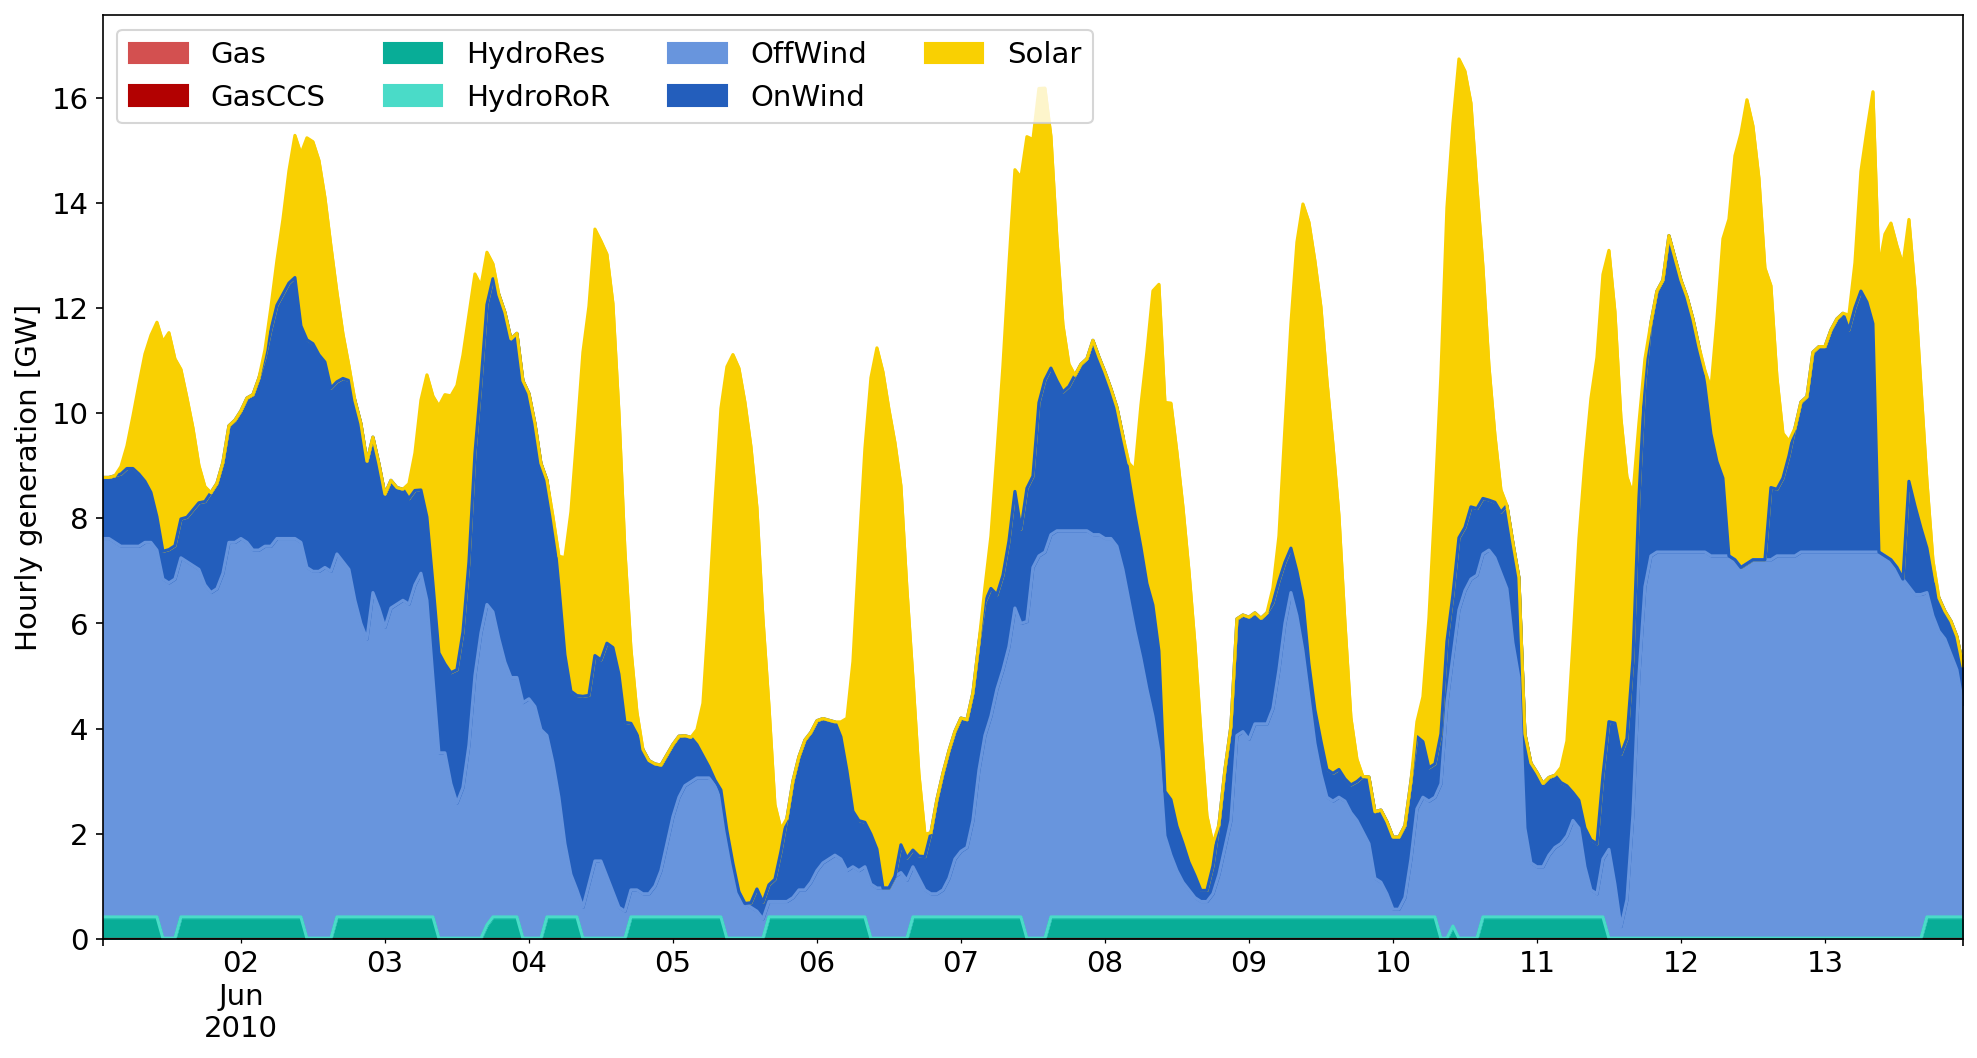

In [127]:
fig, ax = plt.subplots(figsize=(16,8))

(
    gen_PL
    .query("datetime > '2010-06-01' & datetime < '2010-06-14'")
    .replace(nicename)
    .set_index(['datetime','technology'])
    .loc[:,['level']]
    .unstack()
    .droplevel(axis=1, level=0)
    .plot.area(ax=ax,color=colordict,fontsize=14)
)

ax.set_xlabel('',fontsize=14)
ax.set_ylabel('Hourly generation [GW]',fontsize=14)
ax.legend(fontsize=14,ncol=4)
plt.savefig('poland_generation_june.pdf',bbox_inches='tight')

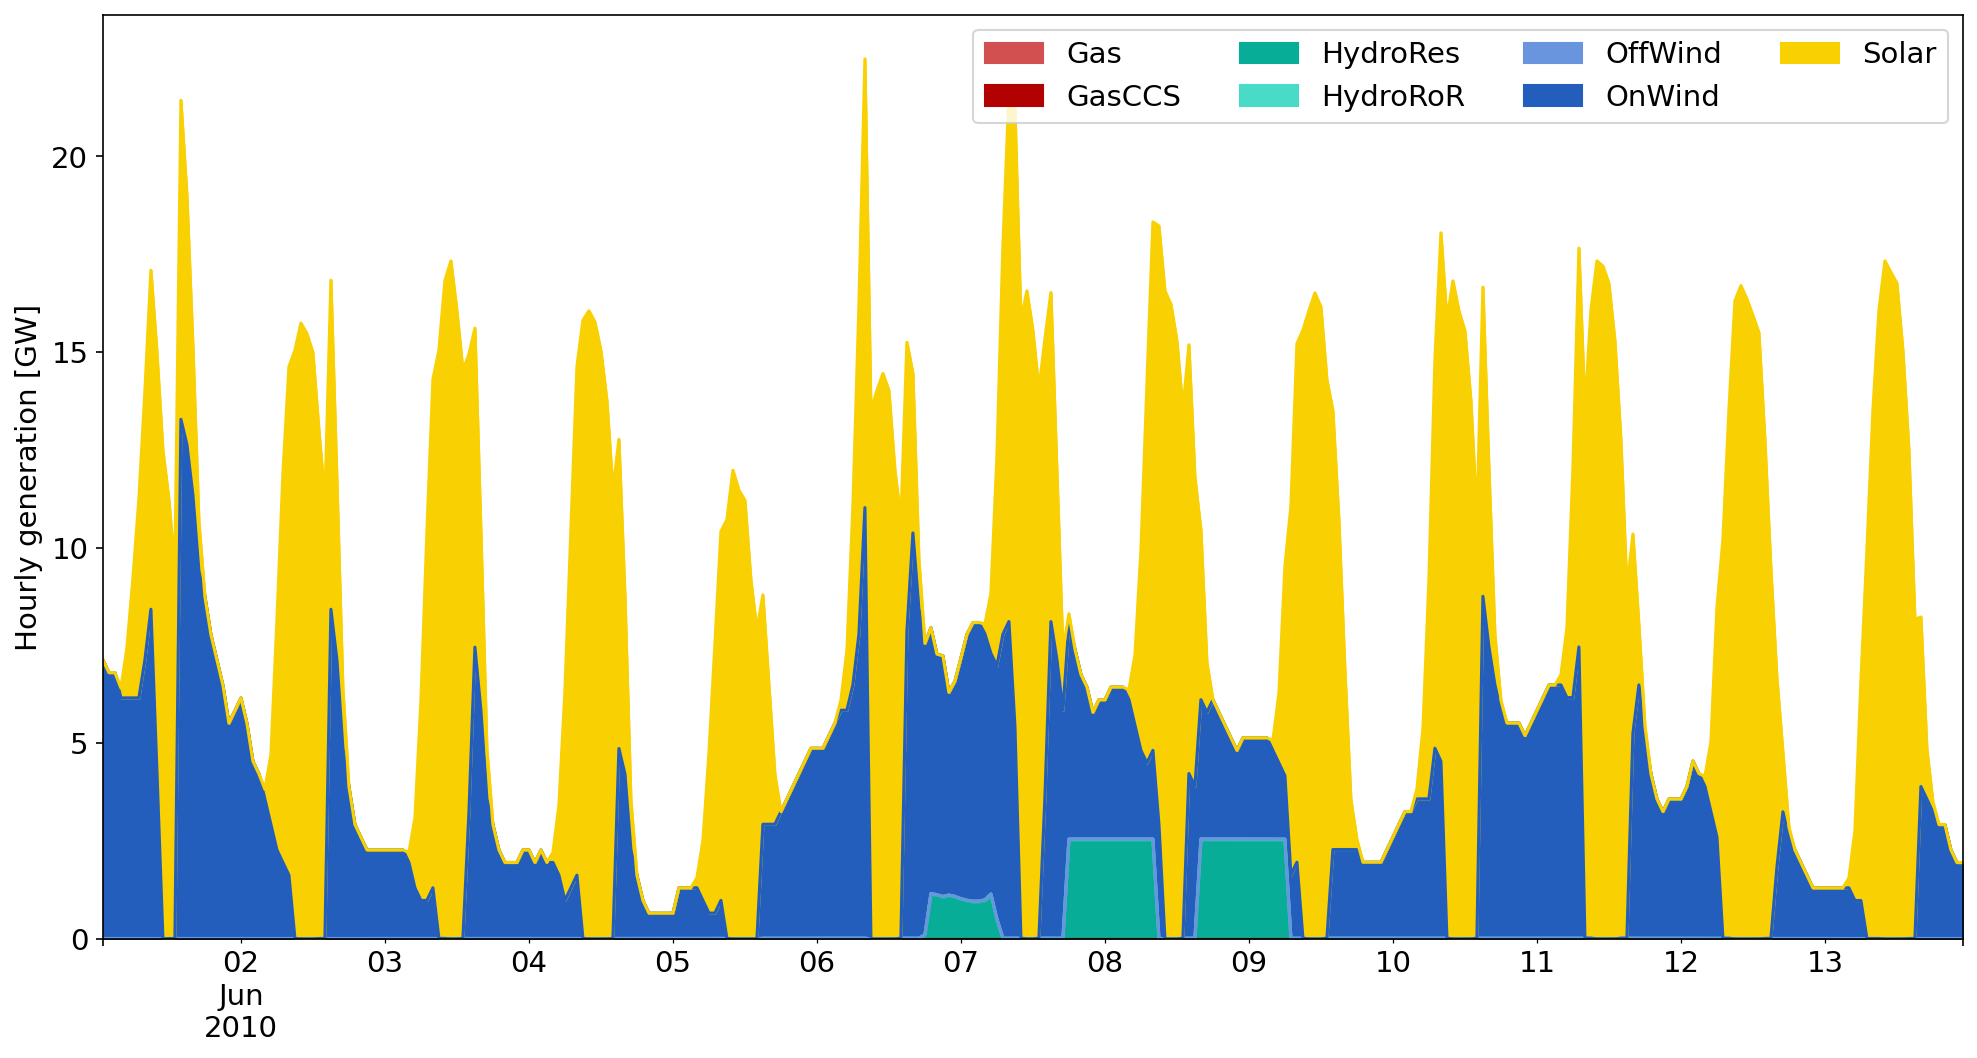

In [125]:
fig, ax = plt.subplots(figsize=(16,8))


(
    gen_GR
    .query("datetime > '2010-06-01' & datetime < '2010-06-14'")
    .replace(nicename)
    .set_index(['datetime','technology'])
    .loc[:,['level']]
    .unstack()
    .droplevel(axis=1, level=0)
    .plot.area(ax=ax,color=colordict,fontsize=14)
)

ax.set_xlabel('',fontsize=14)
ax.set_ylabel('Hourly generation [GW]',fontsize=14)
ax.legend(fontsize=14,ncol=4)
plt.savefig('greece_generation_june.pdf',bbox_inches='tight')